In [1]:
import json
import os
import sys
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, '..')
from transformers import AutoTokenizer

RESULTS_DIR = '../results/gsm8k_sft'
TOKENIZER_PATH = 'Qwen/Qwen2.5-1.5B'

/home/r.dyachenko/miniconda3/envs/llm-alignment/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_PATH)
print('Loaded tokenizer, vocab size:', tokenizer.vocab_size)
print('EOS token:', repr(tokenizer.eos_token), 'id:', tokenizer.eos_token_id)

Loaded tokenizer, vocab size: 151643
EOS token: '<|endoftext|>' id: 151643


In [3]:
# Load all checkpoint results
checkpoints = {}
for fname in sorted(os.listdir(RESULTS_DIR)):
    if fname.endswith('_results.json'):
        name = fname.replace('_results.json', '')
        with open(os.path.join(RESULTS_DIR, fname)) as f:
            checkpoints[name] = json.load(f)

print('Loaded checkpoints:', list(checkpoints.keys()))

Loaded checkpoints: ['checkpoint-1317', 'checkpoint-1756', 'checkpoint-2195', 'checkpoint-2634', 'checkpoint-439', 'checkpoint-878']


In [4]:
# Tokenize responses and get real lengths
def real_lengths(results):
    lengths = []
    for r in results:
        ids = tokenizer.encode(r['response'], add_special_tokens=False)
        lengths.append(len(ids))
    return lengths

# Compute per-checkpoint stats
stats = {}
for name, results in checkpoints.items():
    lengths = real_lengths(results)
    correct = sum(1 for r in results if r['correct'])
    truncated = sum(1 for l in lengths if l >= 502)  # >= max_new_tokens - 10
    stats[name] = {
        'accuracy': correct / len(results),
        'correct': correct,
        'total': len(results),
        'truncated': truncated,
        'truncated_pct': truncated / len(results) * 100,
        'lengths': lengths,
        'mean_len': np.mean(lengths),
        'median_len': np.median(lengths),
        'p95_len': np.percentile(lengths, 95),
    }

# Print summary
print(f"{'Checkpoint':<20} {'Accuracy':>10} {'Truncated':>12} {'Mean len':>10} {'Median':>8} {'P95':>6}")
print('-' * 70)
for name, s in stats.items():
    print(f"{name:<20} {s['accuracy']*100:>9.1f}% {s['truncated']:>6} ({s['truncated_pct']:>4.1f}%) {s['mean_len']:>10.0f} {s['median_len']:>8.0f} {s['p95_len']:>6.0f}")

Checkpoint             Accuracy    Truncated   Mean len   Median    P95
----------------------------------------------------------------------
checkpoint-1317           71.3%      7 ( 0.5%)        127      115    226
checkpoint-1756           71.2%      3 ( 0.2%)        124      113    213
checkpoint-2195           68.2%      2 ( 0.2%)        125      114    219
checkpoint-2634           70.2%      0 ( 0.0%)        125      115    217
checkpoint-439            70.6%      4 ( 0.3%)        125      116    211
checkpoint-878            69.4%      2 ( 0.2%)        121      112    204


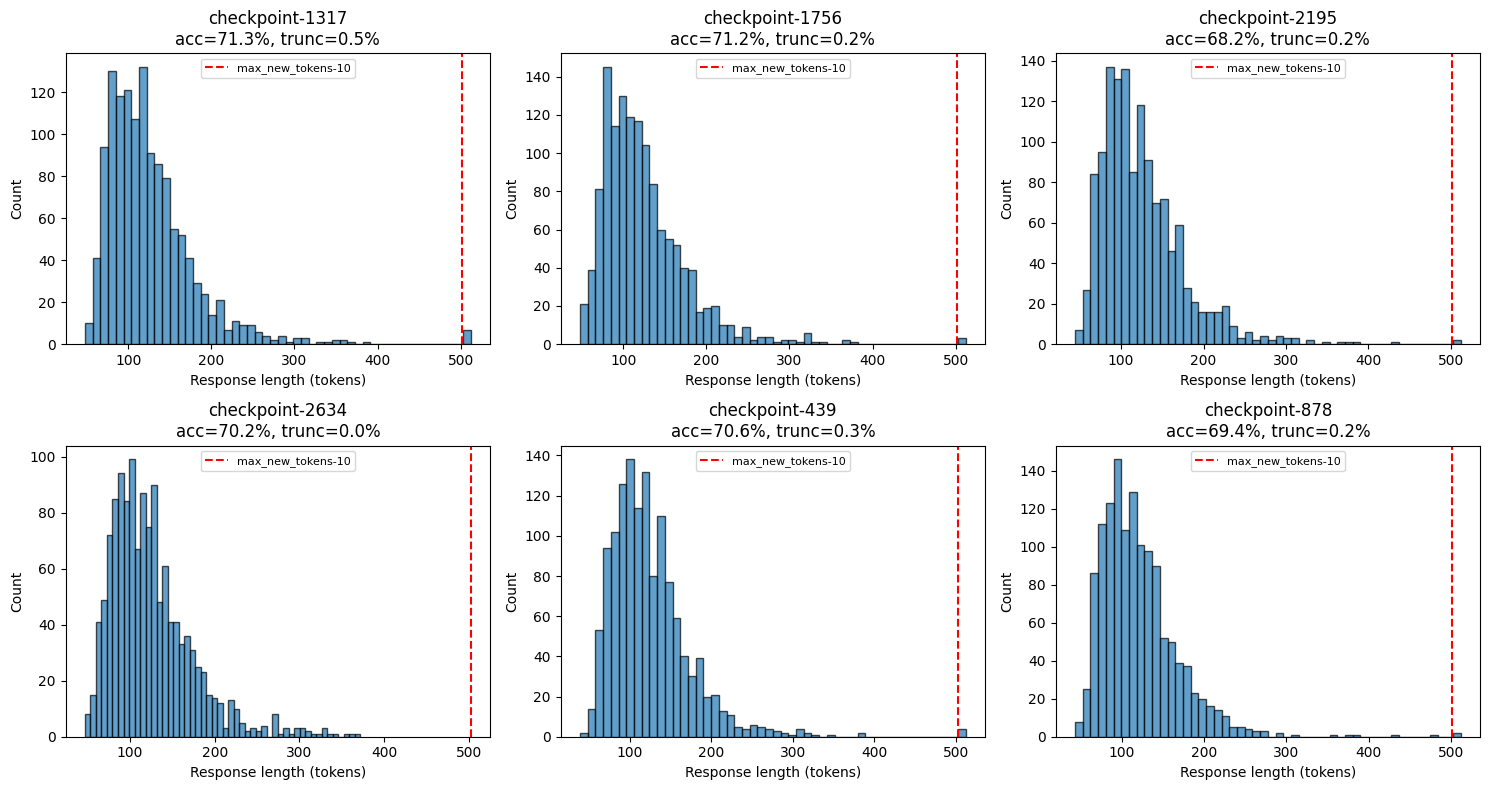

In [5]:
# Response length distributions per checkpoint
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, (name, s) in zip(axes, stats.items()):
    ax.hist(s['lengths'], bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(502, color='red', linestyle='--', label='max_new_tokens-10')
    ax.set_title(f"{name}\nacc={s['accuracy']*100:.1f}%, trunc={s['truncated_pct']:.1f}%")
    ax.set_xlabel('Response length (tokens)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../results/gsm8k_sft/response_length_distributions.png', dpi=150)
plt.show()

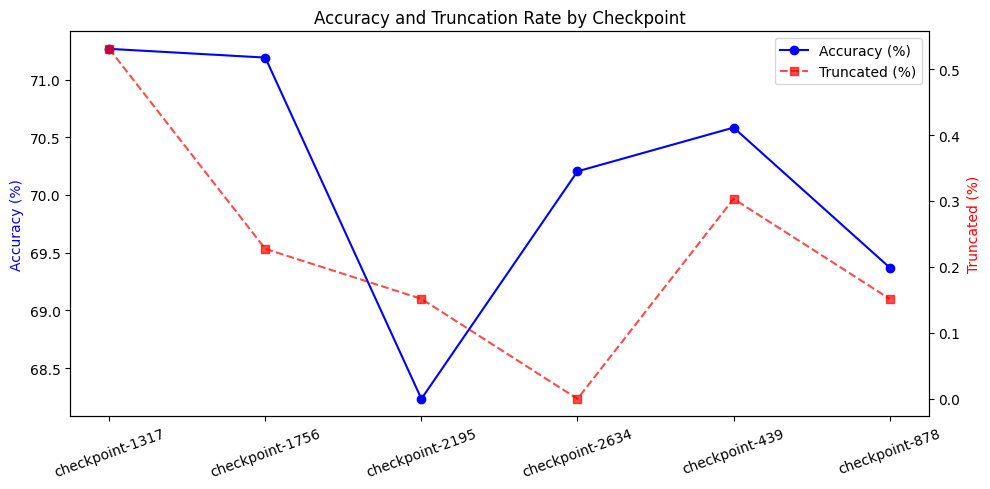

In [6]:
# Accuracy vs epoch
names = list(stats.keys())
accs = [stats[n]['accuracy'] * 100 for n in names]
truncs = [stats[n]['truncated_pct'] for n in names]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(names, accs, 'b-o', label='Accuracy (%)')
ax2.plot(names, truncs, 'r--s', label='Truncated (%)', alpha=0.7)

ax1.set_ylabel('Accuracy (%)', color='blue')
ax2.set_ylabel('Truncated (%)', color='red')
ax1.set_xticks(range(len(names)))
ax1.set_xticklabels(names, rotation=20)
ax1.set_title('Accuracy and Truncation Rate by Checkpoint')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.tight_layout()
plt.savefig('../results/gsm8k_sft/accuracy_vs_truncation.png', dpi=150)
plt.show()

In [7]:
# Посмотрим примеры коротких ответов checkpoint-2634 (почему 0 truncated)
results_2634 = checkpoints.get('checkpoint-2634', [])
lengths_2634 = real_lengths(results_2634)

print('checkpoint-2634 length stats:')
print(f'  min={min(lengths_2634)}, max={max(lengths_2634)}, mean={np.mean(lengths_2634):.0f}')
print(f'  >= 502 tokens: {sum(1 for l in lengths_2634 if l >= 502)}')
print()

# Примеры с самыми короткими ответами
short_idx = sorted(range(len(lengths_2634)), key=lambda i: lengths_2634[i])[:3]
print('=== 3 shortest responses ===')
for i in short_idx:
    r = results_2634[i]
    print(f'  idx={r["idx"]}, len={lengths_2634[i]}, correct={r["correct"]}, gt={r["ground_truth"]}')
    print(f'  response: {repr(r["response"][:200])}')
    print()

checkpoint-2634 length stats:
  min=47, max=372, mean=125
  >= 502 tokens: 0

=== 3 shortest responses ===
  idx=733, len=47, correct=True, gt=5
  response: 'There are a total of 4 siblings. \nIf Greg splits the $20 equally, then each sibling will get $20 / 4 = 5$.\nSo each sibling will get \\boxed{5} dollars.'

  idx=237, len=49, correct=True, gt=90
  response: 'Johnny had $20 + $10 = $30.\nThis sum tripled, so he now has $30 * 3 = $90.\nThus, Johnny had \\boxed{90} dollars after a year.'

  idx=1148, len=52, correct=True, gt=9
  response: 'Three dozen eggs is $3 * 12 = 36$ eggs.\nDividing this number by 4 children we get $36 / 4 = 9$ eggs per child.\nThus each child receives \\boxed{9} eggs.'



In [8]:
# Extraction method breakdown
print(f"{'Checkpoint':<20} {'boxed':>8} {'####':>8} {'last_num':>10} {'no_extract':>12}")
print('-' * 62)
for name, results in checkpoints.items():
    methods = Counter(r['extract_method'] for r in results)
    total = len(results)
    print(f"{name:<20} {methods.get('boxed',0)/total*100:>7.1f}% {methods.get('####',0)/total*100:>7.1f}% {methods.get('last_num',0)/total*100:>9.1f}% {methods.get('no_extract',0)/total*100:>11.1f}%")

Checkpoint              boxed     ####   last_num   no_extract
--------------------------------------------------------------
checkpoint-1317         99.2%     0.0%       0.8%         0.0%
checkpoint-1756         99.6%     0.0%       0.4%         0.0%
checkpoint-2195         99.5%     0.0%       0.5%         0.0%
checkpoint-2634         99.8%     0.0%       0.2%         0.0%
checkpoint-439          99.0%     0.0%       1.0%         0.0%
checkpoint-878          99.6%     0.0%       0.4%         0.0%
